In [1]:
from ridge_regression_functions import *

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_fast")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_fast")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']
SHIFTS = candidate_lags_units(step_ms=100, max_ms=1000)

#SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])


not enough triplets in subject 35, 46 and 60. delete

In [ ]:
import matplotlib.pyplot as plt

# best_shift_by_sub = {}  # best shift per subject
rows_subject = [] 
best_shift_by_sub = []
trim_ms = 200 # TODO fix later
#LAMBDAS = np.logspace(-3, 1.5, 15)
lambdas = [0, 0.1, 1, np.power(10,0.5), 10, np.power(10,2.5)]
DEBUG_SUBJ = [0]
NOT_EVAL_SUBS = [35, 46, 60, 68]  # subjects not evaluated due to too few trials
save_lag_curve = False

for subj in SUBJECTS:
    if subj in NOT_EVAL_SUBS:
        continue
    print(f"Processing subject {subj:02d}...")
    cv_summaries = []  # per-(λ) summaries
    all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)                         # list of (eeg, pupil)
    trials_memory, _ = split_trials_by_condition(all_trials)
    print(f"  Loaded {len(trials_memory)} memory trials")
    loads_mem = [meta["load"] for (_, _, meta) in trials_memory]
    print(f"  Memory loads counts: 5={loads_mem.count(5)}, 9={loads_mem.count(9)}, 13={loads_mem.count(13)}")


    rng = np.random.default_rng(42 + subj)
    mem_triplets = make_triplets_by_load(trials_memory, condition_name="memory", rng=rng)

    print(f"  Number of triplets: {len(mem_triplets)}")
    print(f"  Triplet sizes: {[len(t) for t in mem_triplets]}")

    folds = loto_folds_from_triplets(mem_triplets)
    if not folds:
        print(f"Subject {subj:02d}: not enough trials to form triplets - skipping trial-level CCA.")
        continue

    # ===== cross-validate over λ =====
    final_fit, ordered_results = cross_validate_lambda(lambdas, folds, trials_memory, subj, trim_ms, shifts=SHIFTS, normalise_w=False)

    # Save lambda summaries
    order_sx = pd.DataFrame(ordered_results)
    order_sx.drop(columns=["per_fold"], inplace=True)
    order_sx.to_csv(f"order_ridge_SLOW_k{subj}.csv", index=False)

    # Save lag-corr curve for best λ
    if save_lag_curve:
        lag_df = pd.DataFrame({
            "shift": final_fit["shifts"],
            "r_all": final_fit["rs_shifts"],
            "mse_all": final_fit["mse_shifts"],
        })
        lag_df.to_csv(f"lag_curve_ridge_SLOW_k{subj}.csv", index=False)

    # --- extract key results ---
    lam_star = float(final_fit["lambda"])
    best_shift_star = int(final_fit["best_shift"])
    lag_ms_star = best_shift_star * 10
    w_star = final_fit["w"]
    train_mse_all_star = float(final_fit["train_mse_all"])
    train_rs_all_star  = float(final_fit["train_rs_all"])
    mean_test_mse_star = float(final_fit["cv_mean_test_mse"])
    mean_test_rs_star  = float(final_fit["cv_mean_test_r"])

    X_all, y_all = concat_trials(trials_memory, shift=best_shift_star, trim=trim_ms)
    r_final, p_final = corr_with_weights(X_all, y_all, w_star, return_p=True)
    print(f"[Subject {subj}] FINAL Pearson r = {r_final:.3f}, p = {p_final:.3e}")
    print(f"  Var(y_all) = {y_all.var():.3f}")

    if subj == DEBUG_SUBJ:
        lag_ms_star = int(best_shift_star) * 10

        lags_ms, rs_curve = lag_corr_curve(trials_memory, lam_star, SHIFTS, trim_ms)

        plt.figure()
        plt.plot(lags_ms, rs_curve, marker="o")
        plt.axvline(lag_ms_star, linestyle="--", label=f"chosen lag = {lag_ms_star} ms")
        plt.xlabel("Lag (ms)")
        plt.ylabel("Correlation (train, memory trials)")
        plt.title(f"Subject {subj}_ lag-corr curve (λ={lam_star})")
        plt.legend()
        plt.grid(True)
        plt.show()

    # ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
    # Choose lag+weights on ALL trials (search best lag over SHIFTS)
    best_mse0_all, rs_best_mse0, best_s0, w0_all = np.inf, -np.inf, None, None
    for s in SHIFTS:
        w_s, mse_all, rs_all = fit_at_shift_lambda(trials_memory, int(s), 0.0, trim_ms)
        if np.isfinite(rs_all) and rs_all > rs_best_mse0:
            best_mse0_all, rs_best_mse0, best_s0, w0_all = mse_all, rs_all, int(s), w_s

    fit_lam0 = order_sx[order_sx["lam"] == 0.0].iloc[0]
    mean_test_mse_zero = fit_lam0["mean_test_mse"]
    mean_test_rs_zero = fit_lam0["mean_test_r"]

    lag_ms_zero = int(best_s0) * 10
    train_mse_all_zero = float(best_mse0_all)
    train_rs_all_zero = float(rs_best_mse0)


    rows_subject.append({
        "subject": subj,
        "lam_star": lam_star,
        "best_lag_ms_star": lag_ms_star,
        "train_mse_all_star": float(train_mse_all_star),
        "mean_test_mse_star": float(mean_test_mse_star),
        "train_r_all_star": float(train_rs_all_star),
        "mean_test_r_star": float(mean_test_rs_star),
        "w_star": w_star,
        "best_lag_ms_lam0": lag_ms_zero,
        "train_mse_all_lam0": train_mse_all_zero,
        "mean_test_mse_lam0": mean_test_mse_zero,
        "train_r_all_lam0": train_rs_all_zero,
        "mean_test_lam0": mean_test_rs_zero,
        "w_lam0": w0_all
    })
    X_all, y_all = concat_trials(trials_memory, shift=best_s0, trim=trim_ms)
    r_final0, p_final0 = corr_with_weights(X_all, y_all, w0_all, return_p=True)
    print(f"[Subject {subj}] FINAL λ=0 Pearson r = {r_final0:.3f}, p = {p_final0:.3e}")
    print(f"  Var(y_all) = {y_all.var():.3f}")

    dfk_temp = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
    dfk_temp.to_csv("dfk_ridge_TMP.csv", index=False)

# ---- results table
dfk = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
dfk.to_csv("dfk_ridge.csv", index=False)



Processing subject 33...
  Loaded 106 memory trials
  Memory loads counts: 5=35, 9=35, 13=36
[memory] trials per load: 5→35, 9→35, 13→36
[memory] Created 35 balanced 5–9–13 triplets.
[memory] 1 leftover trials after balanced triplets.
[memory] Attached 1 leftover trial(s) to existing triplets.
[memory] Final triplet counts: 35 groups, sizes=[4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Number of triplets: 35
  Triplet sizes: [4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Lambda 0...
  Fold 1/35...
  Fold 2/35...
  Fold 3/35...
  Fold 4/35...
  Fold 5/35...
  Fold 6/35...
  Fold 7/35...
  Fold 8/35...
  Fold 9/35...
  Fold 10/35...
  Fold 11/35...
  Fold 12/35...
  Fold 13/35...
  Fold 14/35...
  Fold 15/35...
  Fold 16/35...
  Fold 17/35...
  Fold 18/35...
  Fold 19/35...
  Fold 20/35...
  Fold 21/35...
  Fold 22/35...
  Fold 23/35...
  Fold 24/35...
  Fold 25/35..

KeyboardInterrupt: 

In [4]:
## SAVING PREDICTIONS

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

# 1) load your old per-subject best lambdas
dfk_old = pd.read_csv(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv")

# make sure subject is int and lam_star float
dfk_old["subject"] = dfk_old["subject"].astype(int)
dfk_old["lam_star"] = dfk_old["lam_star"].astype(float)

LAM_LOOKUP = dict(zip(dfk_old["subject"], dfk_old["lam_star"]))


# ---- config ----
trim_ms = 200
lambdas = [0, 0.1, 1, np.power(10, 0.5), 10, np.power(10, 2.5)]
NOT_EVAL_SUBS = [35, 46, 60, 68]
save_lag_curve = False

PRED_ROOT = Path("cv_trial_predictions_digit_FAST")  # folder for NPZ + index CSV
PRED_ROOT.mkdir(exist_ok=True, parents=True)

def safe_stem(s: str) -> str:
    # makes filenames safe-ish
    return "".join(c if c.isalnum() or c in ("-", "_") else "_" for c in str(s))

rows_subject = []
pred_index_rows = []   # global index across subjects

for subj in SUBJECTS:
    if subj in NOT_EVAL_SUBS:
        continue

    ## TRAMPas
    lam_star_known = LAM_LOOKUP.get(int(subj), None)
    if lam_star_known is None or not np.isfinite(lam_star_known):
        print(f"Subject {subj:02d}: no lam_star found in old dfk -> skipping")
        continue
    ## trampas end

    print(f"Processing subject {subj:02d}...")
    all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)
    trials_memory, _ = split_trials_by_condition(all_trials)

    print(f"  Loaded {len(trials_memory)} memory trials")
    loads_mem = [meta["load"] for (_, _, meta) in trials_memory]
    print(f"  Memory loads counts: 5={loads_mem.count(5)}, 9={loads_mem.count(9)}, 13={loads_mem.count(13)}")

    rng = np.random.default_rng(42 + subj)
    mem_triplets = make_triplets_by_load(trials_memory, condition_name="memory", rng=rng)

    print(f"  Number of triplets: {len(mem_triplets)}")
    print(f"  Triplet sizes: {[len(t) for t in mem_triplets]}")

    folds = loto_folds_from_triplets(mem_triplets)
    if not folds:
        print(f"Subject {subj:02d}: not enough trials to form triplets - skipping.")
        continue

    # ===== CV over λ (and store held-out trial predictions for λ*) =====
    final_fit, ordered_results = cross_validate_lambda(
        lambdas=[lam_star_known],
        folds=folds,
        trials_memory=trials_memory,
        subj=subj,
        trim_ms=trim_ms,
        shifts=SHIFTS,
        normalise_w=False,
        keep_trial_predictions=True,
    )

    # --- save lambda summary  ---
    order_sx = pd.DataFrame(ordered_results)
    if "per_fold" in order_sx.columns:
        order_sx = order_sx.drop(columns=["per_fold"])
    order_sx.to_csv(f"order_ridge_FAST_k{subj}.csv", index=False)

    # --- save lag curve for best λ (optional) ---
    if save_lag_curve:
        lag_df = pd.DataFrame({
            "shift": final_fit["shifts"],
            "r_all": final_fit["rs_shifts"],
            "mse_all": final_fit["mse_shifts"],
        })
        lag_df.to_csv(f"lag_curve_ridge_FAST_k{subj}.csv", index=False)

    # --- extract key results ---
    lam_star = float(final_fit["lambda"])
    best_shift_star = int(final_fit["best_shift"])
    lag_ms_star = best_shift_star * 10
    w_star = final_fit["w"]

    # --- “refit on all trials” correlation (for reporting weights fit; OK to keep) ---
    X_all, y_all = concat_trials(trials_memory, shift=best_shift_star, trim=trim_ms)
    r_final, p_final = corr_with_weights(X_all, y_all, w_star, return_p=True)
    print(f"[Subject {subj}] FINAL (refit-all) Pearson r = {r_final:.3f}, p = {p_final:.3e}")

    # --- save held-out CV predictions for λ* to disk (NPZ per trial + index row) ---
    subj_pred_dir = PRED_ROOT / f"sub-{subj:02d}"
    subj_pred_dir.mkdir(exist_ok=True, parents=True)

    preds = final_fit.get("cv_trial_predictions", [])  # list of dicts
    for i, pr in enumerate(preds):
        meta = pr["meta"]
        epoch = safe_stem(meta.get("epoch", f"trial{i}"))
        load  = int(meta.get("load", -1))
        fold  = int(pr.get("fold", -1))
        shift = int(pr.get("shift", best_shift_star))
        lag_ms = shift * 10

        fn = subj_pred_dir / f"{epoch}__fold{fold}__lag{lag_ms:+d}ms__lam{lam_star}.npz"
        np.savez_compressed(
            fn,
            y=pr["y"],
            yhat=pr["yhat"],
            lam=lam_star,
            shift=shift,
            lag_ms=lag_ms,
            fold=fold,
            meta=meta,
            align=pr.get("align", {}),
        )

        pred_index_rows.append({
            "subject": subj,
            "epoch": meta.get("epoch", ""),
            "load": load,
            "fold": fold,
            "lam": lam_star,
            "shift_samples": shift,
            "lag_ms": lag_ms,
            "len_aligned": len(pr["y"]),
            "r_trial": pr.get("r_trial", np.nan),
            "mse_trial": pr.get("mse_trial", np.nan),
            "npz_path": str(fn),
        })


    # --- save per-subject summary row (dfk) ---
    rows_subject.append({
        "subject": subj,
        "lam_star": lam_star,
        "best_lag_ms_star": lag_ms_star,
        "train_mse_all_star": float(final_fit["train_mse_all"]),
        "mean_test_mse_star": float(final_fit["cv_mean_test_mse"]),
        "train_r_all_star": float(final_fit["train_rs_all"]),
        "mean_test_r_star": float(final_fit["cv_mean_test_r"]),
        "test_r_recombined": float(final_fit["cv_test_r_recombined"]),
        "test_mse_recombined": float(final_fit["cv_test_mse_recombined"]),
        "w_star": w_star,
        "r_refit_all": float(r_final),
        "p_refit_all": float(p_final),
        "n_cv_pred_trials": int(len(preds)),
    })

    # incremental saves (nice for long runs)
    pd.DataFrame(rows_subject).sort_values("subject").to_csv("dfk_ridge_TMP.csv", index=False)
    pd.DataFrame(pred_index_rows).to_csv(PRED_ROOT / "cv_pred_index_TMP.csv", index=False)

# ---- final outputs
dfk = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
dfk.to_csv("dfk_ridge_extended.csv", index=False)

pred_index = pd.DataFrame(pred_index_rows)
pred_index.to_csv(PRED_ROOT / "cv_pred_index.csv", index=False)
print("Saved:", "dfk_ridge_extended.csv", "and", str(PRED_ROOT / "cv_pred_index.csv"))


Processing subject 33...
  Loaded 106 memory trials
  Memory loads counts: 5=35, 9=35, 13=36
[memory] trials per load: 5→35, 9→35, 13→36
[memory] Created 35 balanced 5–9–13 triplets.
[memory] 1 leftover trials after balanced triplets.
[memory] Attached 1 leftover trial(s) to existing triplets.
[memory] Final triplet counts: 35 groups, sizes=[4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Number of triplets: 35
  Triplet sizes: [4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Lambda 1.0...
  Fold 1/35...
  Fold 2/35...
  Fold 3/35...
  Fold 4/35...
  Fold 5/35...
  Fold 6/35...
  Fold 7/35...
  Fold 8/35...
  Fold 9/35...
  Fold 10/35...
  Fold 11/35...
  Fold 12/35...
  Fold 13/35...
  Fold 14/35...
  Fold 15/35...
  Fold 16/35...
  Fold 17/35...
  Fold 18/35...
  Fold 19/35...
  Fold 20/35...
  Fold 21/35...
  Fold 22/35...
  Fold 23/35...
  Fold 24/35...
  Fold 25/35

KeyboardInterrupt: 

CV predicted trials: 106  / total memory trials: 106
   subject          epoch  load  fold   lam  shift_samples  lag_ms  \
2       33  trial_085.csv    13     0  10.0            200    2000   
3       33  trial_149.csv    13     0  10.0            200    2000   
6       33  trial_135.csv    13     1  10.0            200    2000   

   len_aligned   r_trial  mse_trial  \
2         2440  0.172361   0.993682   
3         2438  0.135103   0.995733   
6         2438 -0.709674   1.014183   

                                            npz_path  
2  cv_trial_predictions_digit\sub-33\trial_085_cs...  
3  cv_trial_predictions_digit\sub-33\trial_149_cs...  
6  cv_trial_predictions_digit\sub-33\trial_135_cs...  


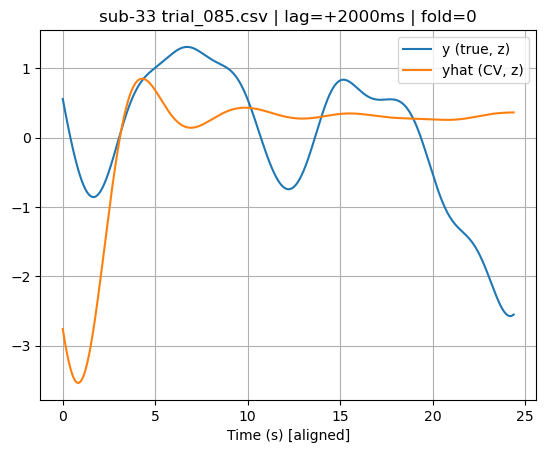

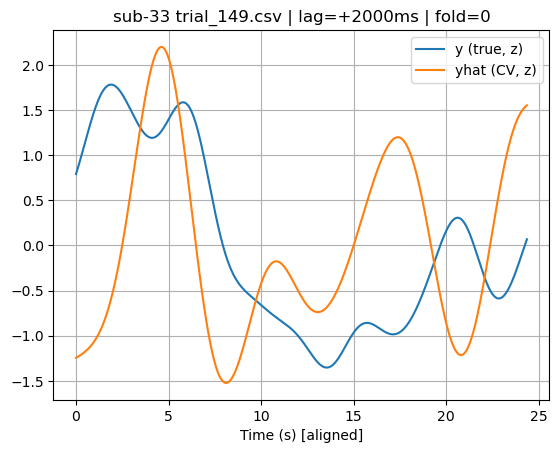

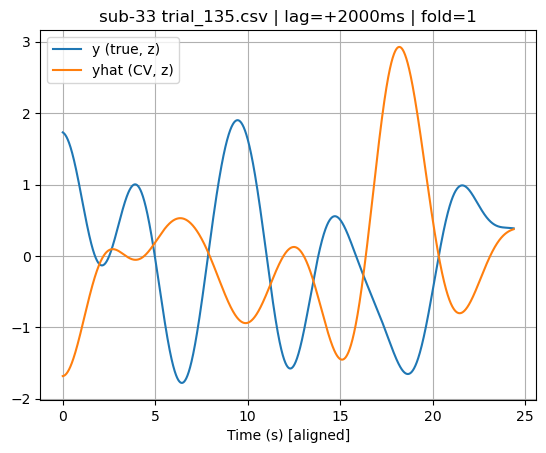

In [9]:
print("CV predicted trials:", len(preds), " / total memory trials:", len(trials_memory))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

idx = pd.read_csv("cv_trial_predictions_digit/cv_pred_index.csv")

# pick 3 trials from subject 12, load=13
sel = idx[(idx.subject == 33) & (idx.load == 13)].head(3)

print(sel)

fs = 100.0  # adjust if needed
for _, row in sel.iterrows():
    z = np.load(row.npz_path, allow_pickle=True)
    y = np.asarray(z["y"]).ravel()
    yhat = np.asarray(z["yhat"]).ravel()

    # z-score per trial
    y_z = (y - y.mean()) / (y.std(ddof=0) + 1e-12)
    yhat_z = (yhat - yhat.mean()) / (yhat.std(ddof=0) + 1e-12)

    t = np.arange(len(y_z)) / fs

    plt.figure()
    plt.plot(t, y_z, label="y (true, z)")
    plt.plot(t, yhat_z, label="yhat (CV, z)")
    plt.title(f"sub-{row.subject:02d} {row.epoch} | lag={row.lag_ms:+d}ms | fold={row.fold}")
    plt.xlabel("Time (s) [aligned]")
    plt.legend()
    plt.grid(True)
    plt.show()



## PLOTS

In [ ]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

folder = r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer"

SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SUBJECTS = [40, 45, 42]
for sub in SUBJECTS:
    path = os.path.join(folder, f"order_ridge_SLOW_k{sub}.csv")
    if not os.path.isfile(path):
        #print(f"[skip] File not found: {path}")
        continue

    df = pd.read_csv(path)

    # Ensure numeric & sort by lam
    num_cols = ["lam", "mean_train_mse", "mean_test_mse",  "mean_train_r", "mean_test_r"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=num_cols).sort_values("lam")

    # ---- find best lambda by test MSE (min) and test r (max) ----
    idx_best_mse = df["mean_test_mse"].idxmin()
    lam_best_mse = df.loc[idx_best_mse, "lam"]

    idx_best_r = df["mean_test_r"].idxmax()
    lam_best_r = df.loc[idx_best_r, "lam"]

    # One figure with two y-axes
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()  # second y-axis sharing same x

    # Left axis: correlations
    l1, = ax1.plot(df["lam"], df["mean_train_r"], marker="o", color="blue",label=r"$\overline{r}_{\text{train}}$")
    l2, = ax1.plot(df["lam"], df["mean_test_r"], marker="s", color="orange", label=r"$\overline{r}_{\text{test}}$")

    ax1.set_xlabel("λ")
    ax1.set_ylabel("r")
    ax1.set_xscale("log")

    # Right axis: MSE
    l3, = ax2.plot(df["lam"], df["mean_train_mse"], marker="^", color="green", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{train}}$")
    l4, = ax2.plot(df["lam"], df["mean_test_mse"], marker="v", color="red", linestyle="--", label=r"$\overline{\text{MSE}}_{\text{test}}$")
    ax2.set_ylabel("MSE")

    # ---- vertical lines for best λs ----
    v1 = ax1.axvline(lam_best_mse, linestyle=":", linewidth=1.5, color="red", label=r"min $\overline{\text{MSE}}_{\text{test}}$")
    v2 = ax1.axvline(lam_best_r, linestyle=":", linewidth=1.5, color="orange", label=r"max $\overline{r}_{\text{test}}$")

    # Title & grid
    fig.suptitle(f"Subject = {sub}")
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Single combined legend
    lines = [l1, l2, l3, l4, v1, v2]
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="best")

    fig.tight_layout()
